# Decision Tree — Hyperparameter Search Strategies
## Wine Quality Dataset (Binary Classification: quality >= 5 vs < 5)
### Hyperparameters: max_depth | min_samples_split | min_samples_leaf | criterion
### Search Methods: Grid Search | Random Search | Successive Halving

---
## SECTION 1 — Load & Explore Dataset

In [37]:
import pandas as pd
import numpy as np

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# df = pd.read_csv("winequality-red.csv")

print('Dataset Shape:', df.shape)
print('Columns:', list(df.columns))
print('\nOriginal Quality Score Distribution:')
print(df['quality'].value_counts().sort_index())
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Original Quality Score Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


---
## SECTION 2 — Binary Conversion + Histogram & Pie Chart

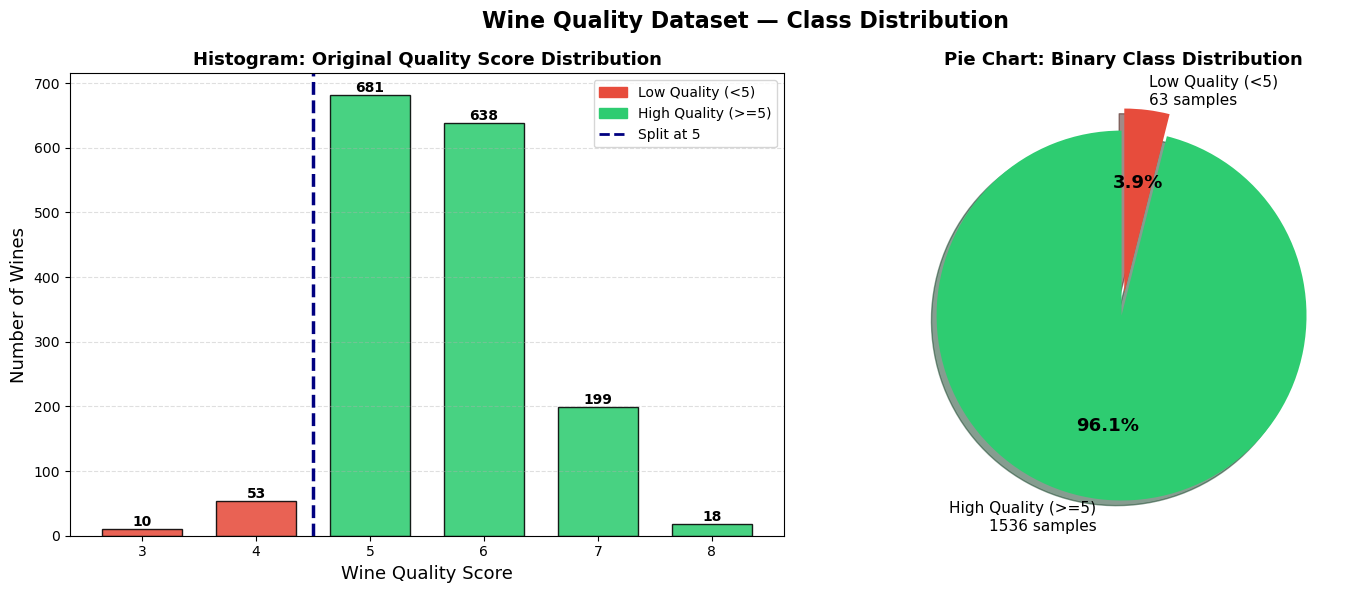

High Quality (>=5): 1536  |  Low Quality (<5): 63


In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Convert to binary: 1 = High Quality (>=5), 0 = Low Quality (<5)
df['binary_quality'] = (df['quality'] >= 5).astype(int)
class_counts = df['binary_quality'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Wine Quality Dataset — Class Distribution', fontsize=16, fontweight='bold')

# --- Histogram ---
quality_counts = df['quality'].value_counts().sort_index()
bar_colors = ['#e74c3c' if q < 5 else '#2ecc71' for q in quality_counts.index]
bars = axes[0].bar(quality_counts.index, quality_counts.values,
                   color=bar_colors, edgecolor='black', alpha=0.88, width=0.7)
axes[0].set_xlabel('Wine Quality Score', fontsize=13)
axes[0].set_ylabel('Number of Wines', fontsize=13)
axes[0].set_title('Histogram: Original Quality Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xticks(quality_counts.index)
axes[0].grid(axis='y', alpha=0.4, linestyle='--')
for bar, val in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].axvline(x=4.5, color='navy', linestyle='--', linewidth=2.5)
p1 = mpatches.Patch(color='#e74c3c', label='Low Quality (<5)')
p2 = mpatches.Patch(color='#2ecc71', label='High Quality (>=5)')
p3 = plt.Line2D([0],[0], color='navy', linestyle='--', linewidth=2, label='Split at 5')
axes[0].legend(handles=[p1, p2, p3], fontsize=10)

# --- Pie Chart ---
labels = [f'High Quality (>=5)\n{class_counts[1]} samples',
          f'Low Quality (<5)\n{class_counts[0]} samples']
wedges, texts, autotexts = axes[1].pie(
    [class_counts[1], class_counts[0]],
    labels=labels, colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
    startangle=90, explode=(0.06, 0.06), shadow=True, textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
axes[1].set_title('Pie Chart: Binary Class Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('dt_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'High Quality (>=5): {class_counts[1]}  |  Low Quality (<5): {class_counts[0]}')

---
## SECTION 3 — Train/Test Split & Scaling

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['quality', 'binary_quality'], axis=1)
y = df['binary_quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {X_train_sc.shape[0]}')
print(f'Test samples     : {X_test_sc.shape[0]}')
print(f'Features         : {X_train_sc.shape[1]}')

Training samples : 1279
Test samples     : 320
Features         : 11


---
## SECTION 4 — Define Hyperparameter Space (Only 4 params)

| Hyperparameter | Values Tested | Role |
|---|---|---|
| `max_depth` | 3, 5, 7, 10, 15, None | Controls tree depth / overfitting |
| `min_samples_split` | 2, 5, 10, 20 | Min samples to split an internal node |
| `min_samples_leaf` | 1, 2, 4, 8 | Min samples at a leaf node |
| `criterion` | gini, entropy | Split quality measure |

In [40]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import accuracy_score

# ====== ONLY 4 HYPERPARAMETERS (no max_features) ======
param_grid = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'criterion'        : ['gini', 'entropy']
}

total_combinations = 6 * 4 * 4 * 2
print(f'Total combinations = 6 x 4 x 4 x 2 = {total_combinations}')
for k, v in param_grid.items():
    print(f'  {k:25s}: {v}')

results = {}
dt_base  = DecisionTreeClassifier(random_state=42)

Total combinations = 6 x 4 x 4 x 2 = 192
  max_depth                : [3, 5, 7, 10, 15, None]
  min_samples_split        : [2, 5, 10, 20]
  min_samples_leaf         : [1, 2, 4, 8]
  criterion                : ['gini', 'entropy']


---
## SECTION 5 — Grid Search CV

In [41]:
start = time.time()
grid_search = GridSearchCV(
    estimator=dt_base, param_grid=param_grid,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_train)
grid_time     = time.time() - start
grid_test_acc = accuracy_score(y_test, grid_search.predict(X_test_sc))

results['Grid Search'] = {
    'best_params'  : grid_search.best_params_,
    'cv_score'     : grid_search.best_score_,
    'test_accuracy': grid_test_acc,
    'time'         : grid_time,
    'n_candidates' : len(grid_search.cv_results_['params'])
}

print('=== GRID SEARCH RESULTS ===')
print(f'  Time Taken       : {grid_time:.2f}s')
print(f'  Candidates Tried : {results["Grid Search"]["n_candidates"]} / {total_combinations}')
print(f'  Best CV Score    : {grid_search.best_score_:.4f}')
print(f'  Test Accuracy    : {grid_test_acc:.4f}')
print(f'  Best Params:')
for k, v in grid_search.best_params_.items():
    print(f'      {k:25s} = {v}')

=== GRID SEARCH RESULTS ===
  Time Taken       : 22.93s
  Candidates Tried : 192 / 192
  Best CV Score    : 0.9601
  Test Accuracy    : 0.9281
  Best Params:
      criterion                 = gini
      max_depth                 = 5
      min_samples_leaf          = 1
      min_samples_split         = 2


---
## SECTION 6 — Random Search CV

In [42]:
from scipy.stats import randint

param_dist = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': randint(2, 21),
    'min_samples_leaf' : randint(1, 9),
    'criterion'        : ['gini', 'entropy']
}

start = time.time()
random_search = RandomizedSearchCV(
    estimator=dt_base, param_distributions=param_dist,
    n_iter=40, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=0
)
random_search.fit(X_train_sc, y_train)
random_time     = time.time() - start
random_test_acc = accuracy_score(y_test, random_search.predict(X_test_sc))

results['Random Search'] = {
    'best_params'  : random_search.best_params_,
    'cv_score'     : random_search.best_score_,
    'test_accuracy': random_test_acc,
    'time'         : random_time,
    'n_candidates' : 40
}

print('=== RANDOM SEARCH RESULTS ===')
print(f'  Time Taken       : {random_time:.2f}s')
print(f'  Candidates Tried : 40 ({40/total_combinations*100:.1f}% of full grid)')
print(f'  Best CV Score    : {random_search.best_score_:.4f}')
print(f'  Test Accuracy    : {random_test_acc:.4f}')
print(f'  Best Params:')
for k, v in random_search.best_params_.items():
    print(f'      {k:25s} = {v}')

=== RANDOM SEARCH RESULTS ===
  Time Taken       : 0.82s
  Candidates Tried : 40 (20.8% of full grid)
  Best CV Score    : 0.9586
  Test Accuracy    : 0.9531
  Best Params:
      criterion                 = gini
      max_depth                 = 3
      min_samples_leaf          = 7
      min_samples_split         = 10


---
## SECTION 7 — Successive Halving

In [43]:
start = time.time()
halving_search = HalvingGridSearchCV(
    estimator=dt_base, param_grid=param_grid,
    cv=5, scoring='accuracy', factor=3,
    min_resources='exhaust', n_jobs=-1, random_state=42, verbose=0
)
halving_search.fit(X_train_sc, y_train)
halving_time     = time.time() - start
halving_test_acc = accuracy_score(y_test, halving_search.predict(X_test_sc))
n_halving_cands  = len(set(str(p) for p in halving_search.cv_results_['params']))

results['Successive Halving'] = {
    'best_params'  : halving_search.best_params_,
    'cv_score'     : halving_search.best_score_,
    'test_accuracy': halving_test_acc,
    'time'         : halving_time,
    'n_candidates' : n_halving_cands
}

print('=== SUCCESSIVE HALVING RESULTS ===')
print(f'  Time Taken       : {halving_time:.2f}s')
print(f'  Candidates Tried : {n_halving_cands} (tournament-style)')
print(f'  Best CV Score    : {halving_search.best_score_:.4f}')
print(f'  Test Accuracy    : {halving_test_acc:.4f}')
print(f'  Best Params:')
for k, v in halving_search.best_params_.items():
    print(f'      {k:25s} = {v}')

=== SUCCESSIVE HALVING RESULTS ===
  Time Taken       : 4.35s
  Candidates Tried : 192 (tournament-style)
  Best CV Score    : 0.9610
  Test Accuracy    : 0.9531
  Best Params:
      criterion                 = gini
      max_depth                 = 3
      min_samples_leaf          = 8
      min_samples_split         = 10


---
## SECTION 8 — Comparison Summary Table

In [44]:
import pandas as pd

summary_df = pd.DataFrame({
    'Time (s)'          : {m: round(results[m]['time'], 3)          for m in results},
    'Candidates'        : {m: results[m]['n_candidates']             for m in results},
    'Best CV Score'     : {m: round(results[m]['cv_score'], 4)       for m in results},
    'Test Accuracy'     : {m: round(results[m]['test_accuracy'], 4)  for m in results},
    'Efficiency (Acc/s)': {m: round(results[m]['test_accuracy']/results[m]['time'], 5) for m in results},
})
summary_df.index.name = 'Method'

print('\n' + '='*70)
print('   DECISION TREE — HYPERPARAMETER SEARCH COMPARISON')
print('='*70)
print(summary_df.to_string())
print('='*70)


   DECISION TREE — HYPERPARAMETER SEARCH COMPARISON
                    Time (s)  Candidates  Best CV Score  Test Accuracy  Efficiency (Acc/s)
Method                                                                                    
Grid Search           22.929         192         0.9601         0.9281             0.04048
Random Search          0.818          40         0.9586         0.9531             1.16452
Successive Halving     4.348         192         0.9610         0.9531             0.21919


---
## SECTION 9 — All 6 Comparison Charts

In [2]:
# import matplotlib.pyplot as plt
# import numpy as np

# methods    = list(results.keys())
# test_accs  = [results[m]['test_accuracy'] for m in methods]
# cv_scores  = [results[m]['cv_score']      for m in methods]
# times      = [results[m]['time']          for m in methods]
# candidates = [results[m]['n_candidates']  for m in methods]
# efficiency = [results[m]['test_accuracy']/results[m]['time'] for m in methods]
# colors     = ['#3498db', '#e67e22', '#2ecc71']

# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# fig.suptitle('Decision Tree — Hyperparameter Search Comparison\n(max_depth | min_samples_split | min_samples_leaf | criterion)',
#              fontsize=15, fontweight='bold')

# # Plot 1: Test Accuracy
# bars = axes[0,0].bar(methods, test_accs, color=colors, edgecolor='black', alpha=0.88)
# axes[0,0].set_title('Test Accuracy by Method', fontsize=12, fontweight='bold')
# axes[0,0].set_ylabel('Accuracy')
# axes[0,0].set_ylim(max(0, min(test_accs)-0.05), 1.0)
# axes[0,0].grid(axis='y', alpha=0.4, linestyle='--')
# for bar, val in zip(bars, test_accs):
#     axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
#                    f'{val:.4f}\n({val*100:.2f}%)', ha='center', fontsize=10, fontweight='bold')

# # Plot 2: Time Taken
# bars2 = axes[0,1].bar(methods, times, color=colors, edgecolor='black', alpha=0.88)
# axes[0,1].set_title('Time Taken (seconds)', fontsize=12, fontweight='bold')
# axes[0,1].set_ylabel('Time (s)')
# axes[0,1].grid(axis='y', alpha=0.4, linestyle='--')
# for bar, val in zip(bars2, times):
#     axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(times)*0.02,
#                    f'{val:.2f}s', ha='center', fontsize=11, fontweight='bold')

# # Plot 3: Candidates Evaluated
# bars3 = axes[0,2].bar(methods, candidates, color=colors, edgecolor='black', alpha=0.88)
# axes[0,2].set_title('Candidates Evaluated', fontsize=12, fontweight='bold')
# axes[0,2].set_ylabel('Count')
# axes[0,2].grid(axis='y', alpha=0.4, linestyle='--')
# axes[0,2].axhline(y=total_combinations, color='red', linestyle='--', linewidth=1.5,
#                   label=f'Total Grid = {total_combinations}')
# axes[0,2].legend(fontsize=9)
# for bar, val in zip(bars3, candidates):
#     axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
#                    str(val), ha='center', fontsize=11, fontweight='bold')

# # Plot 4: CV vs Test Accuracy
# x = np.arange(len(methods))
# w = 0.35
# b1 = axes[1,0].bar(x-w/2, cv_scores, w, label='CV Score', color='#5dade2', edgecolor='black', alpha=0.9)
# b2 = axes[1,0].bar(x+w/2, test_accs, w, label='Test Accuracy', color='#f1948a', edgecolor='black', alpha=0.9)
# axes[1,0].set_title('CV Score vs Test Accuracy', fontsize=12, fontweight='bold')
# axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(methods, fontsize=10)
# axes[1,0].set_ylabel('Score'); axes[1,0].legend(fontsize=10)
# axes[1,0].grid(axis='y', alpha=0.4, linestyle='--')
# axes[1,0].set_ylim(min(cv_scores+test_accs)-0.03, 1.0)
# for bar, val in zip(list(b1)+list(b2), cv_scores+test_accs):
#     axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
#                    f'{val:.3f}', ha='center', fontsize=8)

# # Plot 5: Efficiency
# bars5 = axes[1,1].bar(methods, efficiency, color=colors, edgecolor='black', alpha=0.88)
# axes[1,1].set_title('Efficiency (Accuracy / Second)', fontsize=12, fontweight='bold')
# axes[1,1].set_ylabel('Efficiency Score')
# axes[1,1].grid(axis='y', alpha=0.4, linestyle='--')
# for bar, val in zip(bars5, efficiency):
#     axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(efficiency)*0.02,
#                    f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# # Plot 6: Pie Chart - Time Distribution
# wedges, texts, autotexts = axes[1,2].pie(
#     times, labels=[f'{m}\n({t:.2f}s)' for m, t in zip(methods, times)],
#     colors=colors, autopct='%1.1f%%', startangle=90, explode=[0.05]*3, shadow=True
# )
# for at in autotexts:
#     at.set_fontsize(12); at.set_fontweight('bold')
# axes[1,2].set_title('Pie Chart: Time Distribution by Method', fontsize=12, fontweight='bold')

# plt.tight_layout()
# plt.savefig('dt_comparison_charts.png', dpi=150, bbox_inches='tight')
# plt.show()

---
## SECTION 10 — Hyperparameter Impact Charts (from Grid Search)

In [3]:
# import pandas as pd

# cv_results  = grid_search.cv_results_
# params_df   = pd.DataFrame(cv_results['params'])
# params_df['mean_score'] = cv_results['mean_test_score']

# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# fig.suptitle('Hyperparameter Impact on CV Accuracy (from Grid Search)',
#              fontsize=14, fontweight='bold')

# # max_depth
# d_groups = params_df.groupby('max_depth', dropna=False)['mean_score'].mean()
# xlabs = [str(d) if d is not None else 'None' for d in d_groups.index]
# axes[0,0].bar(xlabs, d_groups.values, color='#3498db', edgecolor='black', alpha=0.85)
# axes[0,0].set_title('Avg CV Accuracy by max_depth', fontsize=12, fontweight='bold')
# axes[0,0].set_xlabel('max_depth'); axes[0,0].set_ylabel('Mean CV Accuracy')
# axes[0,0].grid(axis='y', alpha=0.4, linestyle='--')
# axes[0,0].set_ylim(d_groups.min()-0.02, d_groups.max()+0.02)

# # min_samples_split
# s_groups = params_df.groupby('min_samples_split')['mean_score'].mean()
# axes[0,1].bar(s_groups.index.astype(str), s_groups.values, color='#e67e22', edgecolor='black', alpha=0.85)
# axes[0,1].set_title('Avg CV Accuracy by min_samples_split', fontsize=12, fontweight='bold')
# axes[0,1].set_xlabel('min_samples_split'); axes[0,1].set_ylabel('Mean CV Accuracy')
# axes[0,1].grid(axis='y', alpha=0.4, linestyle='--')
# axes[0,1].set_ylim(s_groups.min()-0.02, s_groups.max()+0.02)

# # min_samples_leaf
# l_groups = params_df.groupby('min_samples_leaf')['mean_score'].mean()
# axes[1,0].bar(l_groups.index.astype(str), l_groups.values, color='#2ecc71', edgecolor='black', alpha=0.85)
# axes[1,0].set_title('Avg CV Accuracy by min_samples_leaf', fontsize=12, fontweight='bold')
# axes[1,0].set_xlabel('min_samples_leaf'); axes[1,0].set_ylabel('Mean CV Accuracy')
# axes[1,0].grid(axis='y', alpha=0.4, linestyle='--')
# axes[1,0].set_ylim(l_groups.min()-0.02, l_groups.max()+0.02)

# # criterion — Pie Chart
# c_groups = params_df.groupby('criterion')['mean_score'].mean()
# crit_labels = [f'{c}\n(avg: {v:.4f})' for c, v in c_groups.items()]
# wedges, texts, autotexts = axes[1,1].pie(
#     c_groups.values, labels=crit_labels, colors=['#9b59b6', '#f39c12'],
#     autopct='%1.2f%%', startangle=90, explode=(0.05, 0.05), shadow=True
# )
# for at in autotexts:
#     at.set_fontsize(12); at.set_fontweight('bold')
# axes[1,1].set_title('Pie Chart: criterion Comparison\n(gini vs entropy)', fontsize=12, fontweight='bold')

# plt.tight_layout()
# plt.savefig('dt_hyperparameter_impact.png', dpi=150, bbox_inches='tight')
# plt.show()

---
## SECTION 11 — Best Model: Classification Report + Confusion Matrix

Best Method   : Random Search
Test Accuracy : 0.9531
Best Params   : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 7, 'min_samples_split': 10}

=== CLASSIFICATION REPORT ===
                    precision    recall  f1-score   support

  Low Quality (<5)       0.00      0.00      0.00        13
High Quality (>=5)       0.96      0.99      0.98       307

          accuracy                           0.95       320
         macro avg       0.48      0.50      0.49       320
      weighted avg       0.92      0.95      0.94       320



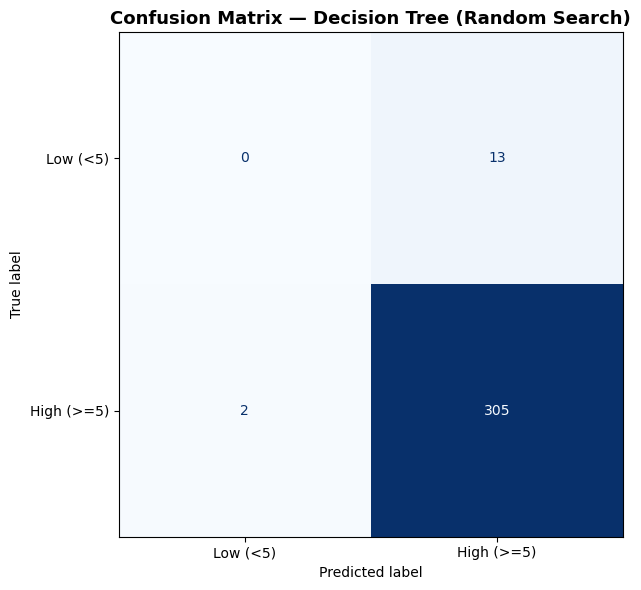

In [47]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_method = max(results, key=lambda m: results[m]['test_accuracy'])
searchers   = {'Grid Search': grid_search, 'Random Search': random_search, 'Successive Halving': halving_search}
best_model  = searchers[best_method].best_estimator_
y_pred      = best_model.predict(X_test_sc)

print(f'Best Method   : {best_method}')
print(f'Test Accuracy : {results[best_method]["test_accuracy"]:.4f}')
print(f'Best Params   : {results[best_method]["best_params"]}')
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Low Quality (<5)', 'High Quality (>=5)']))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Low (<5)', 'High (>=5)'],
    colorbar=False, ax=ax, cmap='Blues'
)
ax.set_title(f'Confusion Matrix — Decision Tree ({best_method})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## SECTION 12 — Final Analysis & Conclusion

In [48]:
fastest       = min(results, key=lambda m: results[m]['time'])
most_accurate = max(results, key=lambda m: results[m]['test_accuracy'])
most_efficient= max(results, key=lambda m: results[m]['test_accuracy']/results[m]['time'])

print('='*70)
print('   DECISION TREE — FINAL ANALYSIS REPORT')
print('   Tuned: max_depth | min_samples_split | min_samples_leaf | criterion')
print('='*70)
print(summary_df.to_string())
print()
print(f'  Fastest Method        : {fastest}  ({results[fastest]["time"]:.2f}s)')
print(f'  Most Accurate Method  : {most_accurate}  ({results[most_accurate]["test_accuracy"]:.4f})')
print(f'  Most Efficient Method : {most_efficient}')
print()
print('SEARCH STRATEGY INSIGHTS:')
print(f'  Grid Search      — Exhaustive. Tries all {total_combinations} combos. Slowest but guaranteed best.')
print('  Random Search    — Tries 40 combos randomly. Fast, near-optimal.')
print('  Succ. Halving    — Tournament-style. Smart resource allocation.')
print()
print('HYPERPARAMETER INSIGHTS:')
print('  max_depth        — Too deep = overfitting. None = unlimited depth = risk of memorizing data.')
print('  min_samples_split— Higher = simpler tree. Prevents over-splitting on noisy data.')
print('  min_samples_leaf — Higher = smoother model. Regularizes the leaf nodes.')
print('  criterion        — gini usually faster. entropy sometimes finds better splits.')
print('='*70)

   DECISION TREE — FINAL ANALYSIS REPORT
   Tuned: max_depth | min_samples_split | min_samples_leaf | criterion
                    Time (s)  Candidates  Best CV Score  Test Accuracy  Efficiency (Acc/s)
Method                                                                                    
Grid Search           22.929         192         0.9601         0.9281             0.04048
Random Search          0.818          40         0.9586         0.9531             1.16452
Successive Halving     4.348         192         0.9610         0.9531             0.21919

  Fastest Method        : Random Search  (0.82s)
  Most Accurate Method  : Random Search  (0.9531)
  Most Efficient Method : Random Search

SEARCH STRATEGY INSIGHTS:
  Grid Search      — Exhaustive. Tries all 192 combos. Slowest but guaranteed best.
  Random Search    — Tries 40 combos randomly. Fast, near-optimal.
  Succ. Halving    — Tournament-style. Smart resource allocation.

HYPERPARAMETER INSIGHTS:
  max_depth        — To